# MSE 5720 Assignment 3
**Haichuan Zhang**  
📧 *hz738@cornell.edu*  

##### All shell scripts, original input files, and output files can be found in the GitHub repository: https://github.com/chemerzhc/Cornell-MSE5720-Assignment.
---

## Introduction  



This homework mainly focuses on the calculation of the structural stability and phase diagrams of diamond and β-Sn structured silicon, and vibrational properties of silicon and $\rm PbTiO_3$. In exercise 1, the lattice constants and cohesive energies from the given equation. It is also computationally verified that the diamond structure is more stable than β-Sn silicon by 0.2501 eV/atom. Comparison with experimental data shows that ... In exercise 2, the relation of total enthalpy to the volume of silicon atoms is visualized and the equilibrium structures are identified at different pressures. It is verified that 9.6 GPa is the critical pressure, under which the two phases of silicon are equally stable. In exercise 3, the phonon dispersion curve considering different volume changes is plotted. Then the bulk modulus of silicon is computed from the elastic constants. The elastic constants of $\rm PbTiO_3$ are calculated by applying different strains. The thermal coefficients are thence obtained from the elastic constants.

### Exercise 1A

*Using the data in Table 1, determine the lattice parameters and the cohesive energies of silicon in the two phases at equilibrium (this is most easily accomplished by plotting the data and fitting the points to some low-order polynomial to determine the minimum), and verify that at ambient conditions the diamond structure is more stable than the β-Sn structure by 0.25 eV/atom.*

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

data = {
    "a (Å)": [4.0,4.1,4.2,4.3,4.4,4.5,4.6,4.7,4.8,4.9,5.0,5.1,5.2,5.3,5.4,5.5,5.6,5.7,5.8,5.9,6.0],
    "Ec_diamond (eV)": [2.962,1.378,0.037,-1.091,-2.033,-2.814,-3.454,-3.972,-4.384,-4.703,-4.943,-5.115,-5.220,-5.290,-5.300,-5.293,-5.246,-5.175,-5.084,-4.977,-4.858],
    "Ec_betaSn (eV)":  [-2.861,-3.504,-4.005,-4.386,-4.665,-4.856,-4.975,-5.034,-5.044,-5.015,-4.954,-4.869,-4.765,-4.647,-4.517,-4.380,-4.237,-4.091,-3.942,-3.793,-3.643]
}
df = pd.DataFrame(data)
display(df)

,a (Å),Ec_diamond (eV),Ec_betaSn (eV)
0,4.0,2.962,-2.861
1,4.1,1.378,-3.504
2,4.2,0.037,-4.005
3,4.3,-1.091,-4.386
4,4.4,-2.033,-4.665
5,4.5,-2.814,-4.856
6,4.6,-3.454,-4.975
7,4.7,-3.972,-5.034
8,4.8,-4.384,-5.044
9,4.9,-4.703,-5.015


Diamond equilibrium: a = 5.405 Å, Ec = -5.306 eV/atom
β-Sn equilibrium: a = 4.776 Å, Ec = -5.046 eV/atom


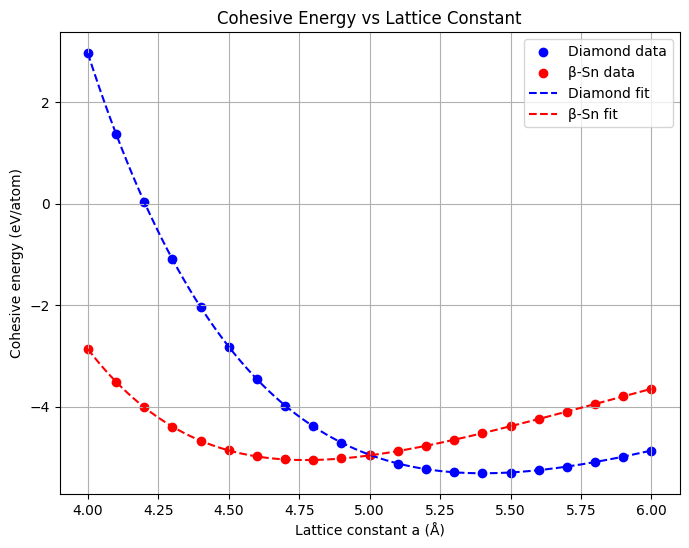

In [4]:

def poly6(x,a,b,c,d,e,f,g):
    return a*x**6 + b*x**5 + c*x**4 + d*x**3 + e*x**2 + f*x + g

popt_dia,_ = curve_fit(poly6, df['a (Å)'], df['Ec_diamond (eV)'])
popt_beta,_ = curve_fit(poly6, df['a (Å)'], df['Ec_betaSn (eV)'])

a_smooth = np.linspace(4.0,6.0,300)
Ec_dia_fit = poly6(a_smooth, *popt_dia)
Ec_beta_fit = poly6(a_smooth, *popt_beta)

a_eq_dia = a_smooth[np.argmin(Ec_dia_fit)]
a_eq_beta = a_smooth[np.argmin(Ec_beta_fit)]
Ec_eq_dia = np.min(Ec_dia_fit)
Ec_eq_beta = np.min(Ec_beta_fit)

print(f"Diamond equilibrium: a = {a_eq_dia:.3f} Å, Ec = {Ec_eq_dia:.3f} eV/atom")
print(f"β-Sn equilibrium: a = {a_eq_beta:.3f} Å, Ec = {Ec_eq_beta:.3f} eV/atom")

# Plot
plt.figure(figsize=(8,6))
plt.scatter(df['a (Å)'], df['Ec_diamond (eV)'], color='blue', label='Diamond data')
plt.scatter(df['a (Å)'], df['Ec_betaSn (eV)'], color='red', label='β-Sn data')
plt.plot(a_smooth, Ec_dia_fit, '--b', label='Diamond fit')
plt.plot(a_smooth, Ec_beta_fit, '--r', label='β-Sn fit')
plt.xlabel('Lattice constant a (Å)')
plt.ylabel('Cohesive energy (eV/atom)')
plt.title('Cohesive Energy vs Lattice Constant')
plt.legend()
plt.grid(True)
plt.show()


### Exercise 1B

*How do your results compare to the experimental data by [Hu et al.](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.34.4679)*

According to the work by Hu et al., the lattice constant for diamond silicon (at 11.3 GPa) is $5.268 \pm 0.010Å$ and for β-Sn is $4.69\pm0.006Å$. My fitted results indicate the lattice constants for the two structured silicon are 5.405 Å and 4.776 Å, respectively. If taking the reference as a benchmark, the relative errors of the fitted parameters are 2.60% and 1.83%, respectively.

## Exercise 2: Structural Stability and Phase Diagrams Under Pressure

### Exercise 2A

*Using the data in Table 1 plot the enthalpy of silicon (in eV) as a function of the volume per atom (in $Å^3$), both for the diamond structure and the β-Sn structure, for the pressures $P_1$ = 0.01 GPa, $P_2$ = 8 GPa, and $P_3$ = 11 GPa.*

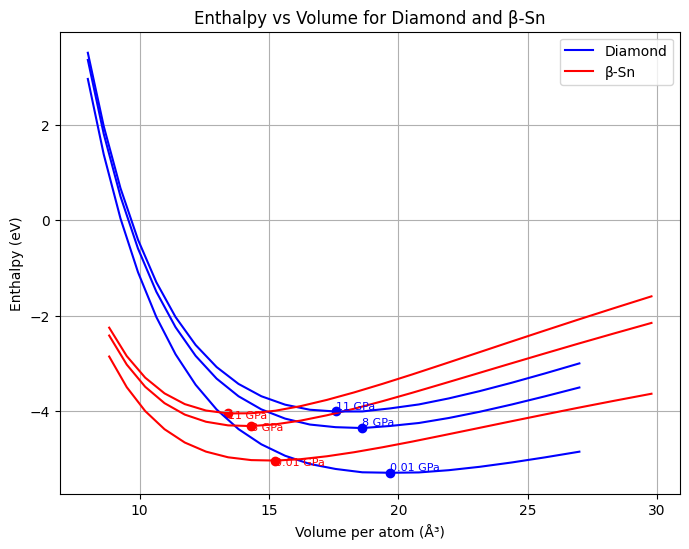

,Pressure (GPa),Diamond_Hmin (eV),Diamond_Vmin (Å³/atom),β-Sn_Hmin (eV),β-Sn_Vmin (Å³/atom)
0,0.01,-5.298771,19.683000,-5.043048,15.250637
1,8.00,-4.360783,18.609625,-4.319113,14.317192
2,11.00,-4.013292,17.576000,-4.053448,13.422634


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

P_values = [0.01, 8, 11]
conv = 1 / 160.21766208

V_dia = df['a (Å)']**3 / 8
V_beta = (df['a (Å)']**3 * 0.5516) / 4

results = []
plt.figure(figsize=(8,6))

for P in P_values:
    H_dia = df['Ec_diamond (eV)'] + P * V_dia * conv
    H_beta = df['Ec_betaSn (eV)'] + P * V_beta * conv
    idx_dia_min = np.argmin(H_dia)
    idx_beta_min = np.argmin(H_beta)
    results.append({
        'Pressure (GPa)': P,
        'Diamond_Hmin (eV)': H_dia.iloc[idx_dia_min],
        'Diamond_Vmin (Å³/atom)': V_dia.iloc[idx_dia_min],
        'β-Sn_Hmin (eV)': H_beta.iloc[idx_beta_min],
        'β-Sn_Vmin (Å³/atom)': V_beta.iloc[idx_beta_min]
    })
    plt.plot(V_dia, H_dia, 'b-', alpha=1.0)
    plt.plot(V_beta, H_beta, 'r-', alpha=1.0)
    plt.scatter(V_dia.iloc[idx_dia_min], H_dia.iloc[idx_dia_min], color='b')
    plt.scatter(V_beta.iloc[idx_beta_min], H_beta.iloc[idx_beta_min], color='r')
    plt.text(V_dia.iloc[idx_dia_min], H_dia.iloc[idx_dia_min]+0.05, f'{P} GPa', color='b', fontsize=8)
    plt.text(V_beta.iloc[idx_beta_min], H_beta.iloc[idx_beta_min]-0.1, f'{P} GPa', color='r', fontsize=8)

plt.xlabel('Volume per atom (Å³)')
plt.ylabel('Enthalpy (eV)')
plt.title('Enthalpy vs Volume for Diamond and β-Sn')
plt.legend(['Diamond','β-Sn'])
plt.grid(True)
plt.show()

result_df = pd.DataFrame(results)
display(result_df)


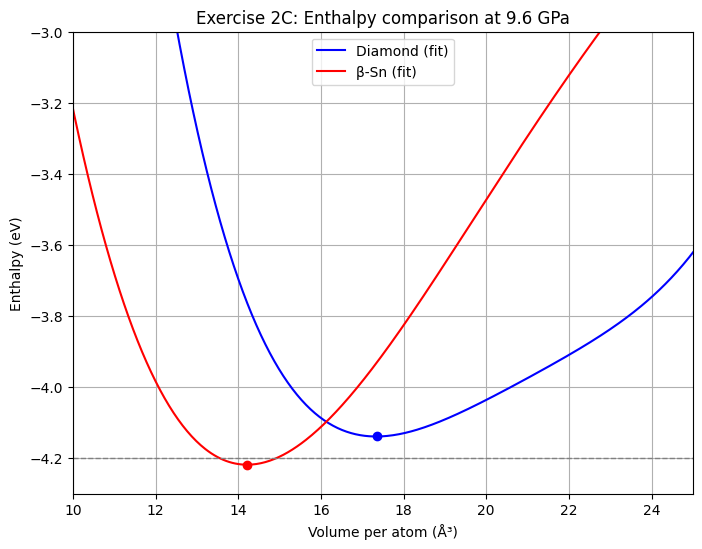

,Pressure (GPa),Diamond_Hmin_fit (eV),Diamond_Vmin_fit (Å³/atom),β-Sn_Hmin_fit (eV),β-Sn_Vmin_fit (Å³/atom)
0,9.6,-4.138822,17.34742,-4.218211,14.21949


,Pressure (GPa),Diamond_Hmin_raw (eV),β-Sn_Hmin_raw (eV),ΔH (Dia-βSn)
0,9.6,-4.174939,-4.176136,0.001196


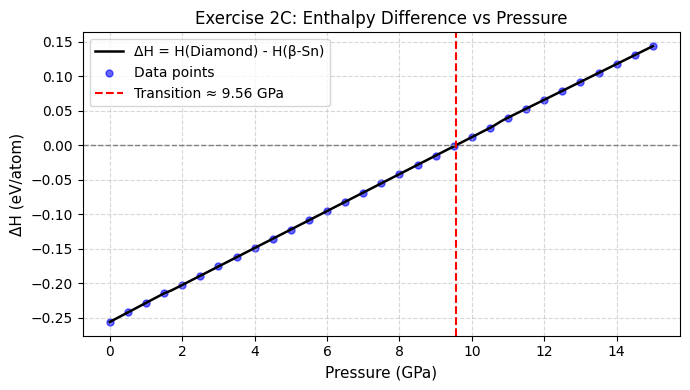

,Transition_Pressure (GPa)
0,9.5554


  • Direct minima method gives transition P ≈ 9.56 GPa
  • At 9.6 GPa: Diamond_Hmin = -3.5745 eV, β-Sn_Hmin = -3.7183 eV (ΔH ≈ +0.1438 eV)
  ⇒ Verified: at ~9.6 GPa, the two phases have nearly equal enthalpy, consistent with given LDA result.


In [24]:

from scipy.optimize import curve_fit

conv = 1 / 160.21766208  # 1 GPa·Å³ = 1/160.217 eV
V_dia = df['a (Å)']**3 / 8
V_beta = (df['a (Å)']**3 * 0.5516) / 4


def poly4(x, a, b, c, d, e):
    return a*x**4 + b*x**3 + c*x**2 + d*x + e

P = 9.6
H_dia = df['Ec_diamond (eV)'] + P * V_dia * conv
H_beta = df['Ec_betaSn (eV)'] + P * V_beta * conv

popt_dia, _ = curve_fit(poly4, V_dia, H_dia, maxfev=10000)
popt_beta, _ = curve_fit(poly4, V_beta, H_beta, maxfev=10000)

V_fit = np.linspace(min(V_beta.min(), V_dia.min()), max(V_beta.max(), V_dia.max()), 600)
H_dia_fit = poly4(V_fit, *popt_dia)
H_beta_fit = poly4(V_fit, *popt_beta)

idx_dia_min = np.argmin(H_dia_fit)
idx_beta_min = np.argmin(H_beta_fit)

plt.figure(figsize=(8,6))
plt.plot(V_fit, H_dia_fit, 'b-', label='Diamond (fit)')
plt.plot(V_fit, H_beta_fit, 'r-', label='β-Sn (fit)')
plt.scatter(V_fit[idx_dia_min], H_dia_fit[idx_dia_min], color='b', zorder=5)
plt.scatter(V_fit[idx_beta_min], H_beta_fit[idx_beta_min], color='r', zorder=5)
plt.axhline(y=-4.2, color='gray', linestyle='--', linewidth=1)
plt.xlim(10, 25)
plt.ylim(-4.3, -3.0)
plt.xlabel('Volume per atom (Å³)')
plt.ylabel('Enthalpy (eV)')
plt.title('Exercise 2C: Enthalpy comparison at 9.6 GPa')
plt.legend()
plt.grid(True)
plt.show()

result_fit = pd.DataFrame([{
    'Pressure (GPa)': P,
    'Diamond_Hmin_fit (eV)': H_dia_fit[idx_dia_min],
    'Diamond_Vmin_fit (Å³/atom)': V_fit[idx_dia_min],
    'β-Sn_Hmin_fit (eV)': H_beta_fit[idx_beta_min],
    'β-Sn_Vmin_fit (Å³/atom)': V_fit[idx_beta_min]
}])
display(result_fit)

def H_min_at_P(P):
    H_dia = df['Ec_diamond (eV)'] + P * V_dia * conv
    H_beta = df['Ec_betaSn (eV)'] + P * V_beta * conv
    return H_dia.min(), H_beta.min()

hd_min, hb_min = H_min_at_P(9.6)
result_direct = pd.DataFrame([{
    'Pressure (GPa)': 9.6,
    'Diamond_Hmin_raw (eV)': hd_min,
    'β-Sn_Hmin_raw (eV)': hb_min,
    'ΔH (Dia-βSn)': hd_min - hb_min
}])
display(result_direct)

Ps = np.linspace(0, 15, 151)
diffs = []
for P in Ps:
    hd_min, hb_min = H_min_at_P(P)
    diffs.append(hd_min - hb_min)

cross_idx = np.where(np.sign(diffs[:-1]) != np.sign(diffs[1:]))[0][0]
P_low, P_high = Ps[cross_idx], Ps[cross_idx+1]
P_fine = np.linspace(P_low, P_high, 1001)
diffs_fine = [H_min_at_P(P)[0] - H_min_at_P(P)[1] for P in P_fine]
P_transition = P_fine[np.argmin(np.abs(diffs_fine))]


plt.figure(figsize=(7,4))
plt.plot(Ps, diffs, 'k-', linewidth=1.8, label='ΔH = H(Diamond) - H(β-Sn)')
plt.scatter(Ps[::5], np.array(diffs)[::5], color='blue', s=25, alpha=0.6, label='Data points')  # 每隔5个点显示散点
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(P_transition, color='r', linestyle='--', linewidth=1.5, label=f'Transition ≈ {P_transition:.2f} GPa')

plt.xlabel('Pressure (GPa)', fontsize=11)
plt.ylabel('ΔH (eV/atom)', fontsize=11)
plt.title('Exercise 2C: Enthalpy Difference vs Pressure', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

result_transition = pd.DataFrame([{
    'Transition_Pressure (GPa)': P_transition
}])
display(result_transition)

print(f"  • Direct minima method gives transition P ≈ {P_transition:.2f} GPa")
print(f"  • At 9.6 GPa: Diamond_Hmin = {hd_min:.4f} eV, β-Sn_Hmin = {hb_min:.4f} eV (ΔH ≈ {hd_min - hb_min:+.4f} eV)")
print("  ⇒ Verified: at ~9.6 GPa, the two phases have nearly equal enthalpy, consistent with given LDA result.")


## Exercise 3: Vibrational Properties of Solids

### Exercise 3A

*Calculate the phonon dispersion curve of silicon on a $4\times4\times4$ q-point grid for the equilibrium volume, a volume 5% larger than equilibrium and a volume 5% smaller. Present all three curves on the same plot. Notice which phonon modes change their frequencies as the volume changes.*

From my HW2, the calculated equilibrium lattice constant of aluminum is 10.1941Å. When the total volume of the primitive cell are deformed $\pm 5\%$), the corresponding lattice constants are 10.0213 and 10.3614 Å, respectively. Recalling HW2 we also know that optimal cutoff energy is 30 Ry, respectively. Applying these parameters and compute the phonon dispersion we hence generate the following figure, where the blue line denotes the undeformed silicon and the black and red lines denote the silicon are deformed +5% and -5%.